# 02 — Data augmentation et rééquilibrage des classes

Ce notebook correspond à l'exercice 1.2 du projet.  
L'objectif est de définir une stratégie de data augmentation adaptée aux images de plaies et de préparer les mécanismes de rééquilibrage des classes minoritaires.

L'analyse exploratoire a montré que le dataset contient 431 images réparties en 7 classes, avec un ratio de déséquilibre max/min de 5,3.  
Les augmentations doivent donc enrichir le jeu d'entraînement sans modifier artificiellement les caractéristiques médicales importantes des plaies.

In [18]:
from pathlib import Path
from PIL import Image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from torchvision.transforms import InterpolationMode

SPLIT_DIR = Path("../data/processed/splits")

train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

train_df.head()

Train: 301
Validation: 65
Test: 65


,path,class,filename,extension,width,height,mode,ratio
0,../data/raw/Bruises/bruises (23).jpg,Bruises,bruises (23).jpg,.jpg,640,640,RGB,1.0
1,../data/raw/Cut/cut (24).jpg,Cut,cut (24).jpg,.jpg,640,640,RGB,1.0
2,../data/raw/Abrasions/abrasions (84).jpg,Abrasions,abrasions (84).jpg,.jpg,640,640,RGB,1.0
3,../data/raw/Stab_wound/stab_wound (10).jpg,Stab_wound,stab_wound (10).jpg,.jpg,640,640,RGB,1.0
4,../data/raw/Cut/cut (5).jpg,Cut,cut (5).jpg,.jpg,640,640,RGB,1.0


In [19]:
split_distribution = pd.DataFrame({
    "train": train_df["class"].value_counts(),
    "validation": val_df["class"].value_counts(),
    "test": test_df["class"].value_counts()
}).fillna(0).astype(int)

split_distribution["total"] = split_distribution.sum(axis=1)

split_distribution

,train,validation,test,total
class,,,,
Abrasions,59,13,13,85
Bruises,85,18,19,122
Burns,41,9,9,59
Cut,35,8,7,50
Ingrown_nails,22,4,5,31
Laceration,43,9,9,61
Stab_wound,16,4,3,23


## Définition des transformations

Pour les images de plaies, on reste prudent. On autorise :

- redimensionnement
- rotations modérées
- flips horizontaux/verticaux
- légères variations de luminosité/contraste
- léger zoom/cadrage

On évite :

- inversion de couleur
- transformations trop fortes
- flou excessif
- déformation géométrique agressive

In [20]:
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15, fill=0),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
class_names = sorted(train_df["class"].unique())

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

print(class_to_idx)

{'Abrasions': 0, 'Bruises': 1, 'Burns': 2, 'Cut': 3, 'Ingrown_nails': 4, 'Laceration': 5, 'Stab_wound': 6}


## Création des datasets

In [22]:
class WoundDataset(Dataset):
    def __init__(self, dataframe, transform=None, class_to_idx=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = row["path"]
        class_name = row["class"]
        
        image = Image.open(image_path).convert("RGB")
        label = self.class_to_idx[class_name]
        
        if self.transform is not None:
            image = self.transform(image)
        
        return image, label

In [23]:
train_dataset = WoundDataset(
    dataframe=train_df,
    transform=train_transforms,
    class_to_idx=class_to_idx
)

val_dataset = WoundDataset(
    dataframe=val_df,
    transform=eval_transforms,
    class_to_idx=class_to_idx
)

test_dataset = WoundDataset(
    dataframe=test_df,
    transform=eval_transforms,
    class_to_idx=class_to_idx
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 301
Validation dataset: 65
Test dataset: 65


## Verification visuelle des transformations des images

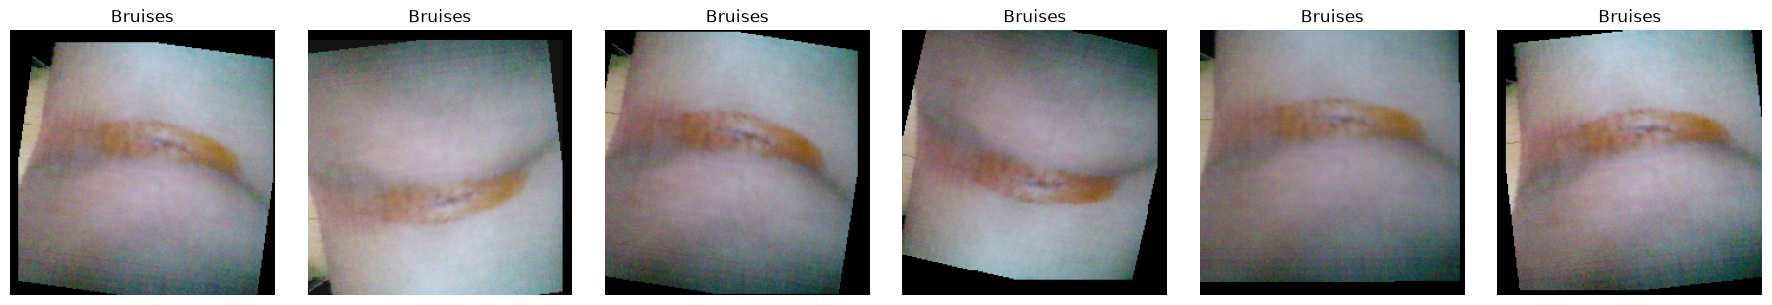

In [24]:
def denormalize_tensor(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    image_tensor = image_tensor * std + mean
    image_tensor = image_tensor.clamp(0, 1)
    
    return image_tensor


def show_augmented_versions(dataset, image_index=0, n=6):
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    
    for i in range(n):
        image, label = dataset[image_index]
        image = denormalize_tensor(image).permute(1, 2, 0).numpy()
        
        axes[i].imshow(image)
        axes[i].axis("off")
        axes[i].set_title(idx_to_class[label])
    
    plt.tight_layout()
    plt.show()


show_augmented_versions(train_dataset, image_index=0, n=6)

### Calcul des poids de classes

In [25]:
class_counts = train_df["class"].value_counts().sort_index()
class_counts = class_counts[class_names]

num_classes = len(class_names)
num_train_samples = len(train_df)

class_weights = num_train_samples / (num_classes * class_counts)

class_weights_df = pd.DataFrame({
    "class": class_names,
    "train_count": class_counts.values,
    "class_weight": class_weights.values
})

class_weights_df

,class,train_count,class_weight
0,Abrasions,59,0.728814
1,Bruises,85,0.505882
2,Burns,41,1.048780
3,Cut,35,1.228571
4,Ingrown_nails,22,1.954545
5,Laceration,43,1.000000
6,Stab_wound,16,2.687500


In [26]:
sample_weights = train_df["class"].map(class_weights.to_dict()).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights.copy()),
    num_samples=len(sample_weights),
    replacement=True
)

print(f"Nombre d'échantillons pondérés : {len(sample_weights)}")
print(f"Nombre d'échantillons tirés par époque : {len(sampler)}")
print(f"Poids minimal : {sample_weights.min():.4f}")
print(f"Poids maximal : {sample_weights.max():.4f}")

Nombre d'échantillons pondérés : 301
Nombre d'échantillons tirés par époque : 301
Poids minimal : 0.5059
Poids maximal : 2.6875


### DataLoaders avec et sans rééquilibrage

In [27]:
BATCH_SIZE = 16

train_loader_baseline = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

train_loader_weighted = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Nombre de batchs train baseline : {len(train_loader_baseline)}")
print(f"Nombre de batchs train weighted : {len(train_loader_weighted)}")
print(f"Nombre de batchs validation : {len(val_loader)}")
print(f"Nombre de batchs test : {len(test_loader)}")

Nombre de batchs train baseline : 19
Nombre de batchs train weighted : 19
Nombre de batchs validation : 5
Nombre de batchs test : 5


In [28]:
def inspect_loader_distribution(loader, idx_to_class, max_batches=None):
    counts = {class_name: 0 for class_name in idx_to_class.values()}
    
    for batch_idx, (_, labels) in enumerate(loader):
        for label in labels.numpy():
            class_name = idx_to_class[int(label)]
            counts[class_name] += 1
        
        if max_batches is not None and batch_idx + 1 >= max_batches:
            break
    
    return pd.DataFrame({
        "class": list(counts.keys()),
        "sampled_count": list(counts.values())
    }).sort_values("class")


baseline_sampled_distribution = inspect_loader_distribution(
    train_loader_baseline,
    idx_to_class
)

weighted_sampled_distribution = inspect_loader_distribution(
    train_loader_weighted,
    idx_to_class
)

baseline_sampled_distribution, weighted_sampled_distribution

(           class  sampled_count
 0      Abrasions             59
 1        Bruises             85
 2          Burns             41
 3            Cut             35
 4  Ingrown_nails             22
 5     Laceration             43
 6     Stab_wound             16,
            class  sampled_count
 0      Abrasions             44
 1        Bruises             39
 2          Burns             34
 3            Cut             45
 4  Ingrown_nails             54
 5     Laceration             46
 6     Stab_wound             39)

## Comparaison visuelle baseline vs weighted sampler

In [29]:
comparison_df = baseline_sampled_distribution.merge(
    weighted_sampled_distribution,
    on="class",
    suffixes=("_baseline", "_weighted")
)

comparison_df

,class,sampled_count_baseline,sampled_count_weighted
0,Abrasions,59,44
1,Bruises,85,39
2,Burns,41,34
3,Cut,35,45
4,Ingrown_nails,22,54
5,Laceration,43,46
6,Stab_wound,16,39


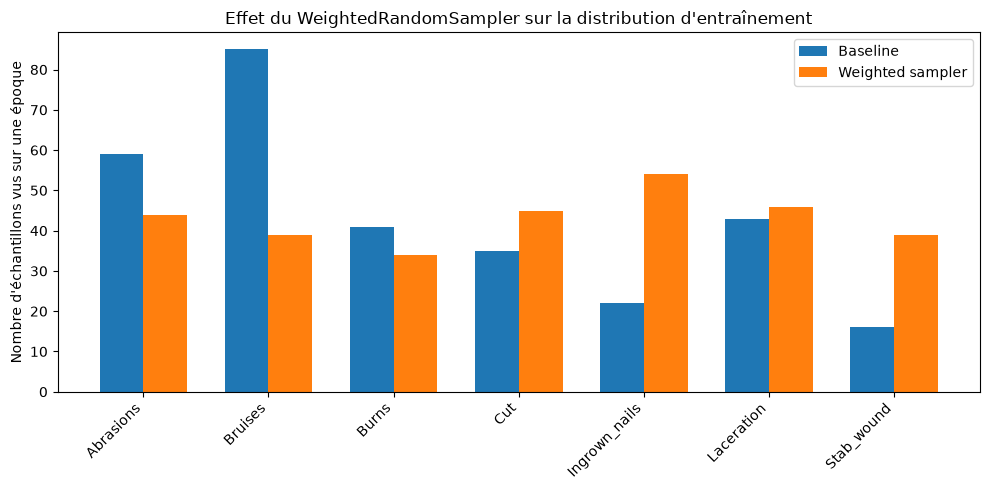

In [30]:
x = np.arange(len(comparison_df))
width = 0.35

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, comparison_df["sampled_count_baseline"], width, label="Baseline")
plt.bar(x + width/2, comparison_df["sampled_count_weighted"], width, label="Weighted sampler")

plt.xticks(x, comparison_df["class"], rotation=45, ha="right")
plt.ylabel("Nombre d'échantillons vus sur une époque")
plt.title("Effet du WeightedRandomSampler sur la distribution d'entraînement")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weighted_sampler_effect.png", dpi=300)
plt.show()

## Conclusion sur la stratégie d'augmentation et de rééquilibrage

La stratégie retenue repose sur une augmentation en ligne appliquée uniquement au jeu d'entraînement. Les transformations choisies restent volontairement modérées afin de conserver la cohérence clinique des images : rotations limitées, retournements, légères variations de luminosité et de contraste, translations et zooms faibles.

Certaines transformations ont été exclues, notamment l'inversion de couleurs, les déformations agressives ou les altérations fortes de teinte, car elles peuvent modifier l'apparence médicale de la plaie et introduire des exemples artificiels peu réalistes.

Compte tenu du déséquilibre important observé lors de l'analyse exploratoire, deux stratégies de rééquilibrage seront comparées lors de l'entraînement : l'utilisation d'un `WeightedRandomSampler`, qui expose plus fréquemment le modèle aux classes minoritaires, et l'utilisation de poids de classes dans la fonction de perte, qui pénalise davantage les erreurs sur ces classes.

Ces stratégies seront évaluées à partir des métriques par classe, en particulier le rappel et le F1-score des classes minoritaires `Ingrown_nails` et `Stab_wound`.